In [1]:
import subprocess, sys, os

def sh(cmd):
    subprocess.run(cmd, shell=True, check=False)

sh(f"{sys.executable} -m pip install -q --no-cache-dir --force-reinstall 'Pillow==11.2.1'")

sh(f"{sys.executable} -m pip install -q "
   "'transformers>=4.40,<4.50' 'tokenizers<0.21' 'huggingface-hub<0.26' "
   "'sentence-transformers>=2.7' 'keybert>=0.8' "
   "pypdf pdfplumber requests networkx pyvis rich spacy safetensors sentencepiece")
sh(f"{sys.executable} -m spacy download en_core_web_sm -q")

In [2]:
try:
    import PIL
    from PIL import _typing as _pt
    if not hasattr(_pt, "_Ink"):
        raise ImportError("Pillow missing _Ink — needs upgrade")
    print(f"[OK] Pillow {PIL.__version__} works")
except Exception as e:
    print("=" * 62)
    print("Pillow is still broken in this session.")
    print("Please: Runtime > Restart session, then run this cell again.")
    print("=" * 62)
    os._exit(0)


[OK] Pillow 12.3.0 works


In [3]:
import requests, pathlib

PAPER_ID = "1706.03762"
pdf_path = pathlib.Path(f"{PAPER_ID}.pdf")
if not pdf_path.exists():
    r = requests.get(
        f"https://arxiv.org/pdf/{PAPER_ID}.pdf",
        headers={"User-Agent": "ResearchMindAI/0.1"}, timeout=60,
    )
    r.raise_for_status()
    pdf_path.write_bytes(r.content)
print(f"[OK] downloaded {pdf_path} ({pdf_path.stat().st_size/1024:.0f} KB)\n")

[OK] downloaded 1706.03762.pdf (2163 KB)



In [4]:
import re, unicodedata
from pypdf import PdfReader

reader = PdfReader(str(pdf_path))
raw_text = "\n".join((p.extract_text() or "") for p in reader.pages)

LIG = {"ﬁ": "fi", "ﬂ": "fl", "ﬀ": "ff", "ﬃ": "ffi", "ﬄ": "ffl"}
def clean(t):
    for k, v in LIG.items(): t = t.replace(k, v)
    t = unicodedata.normalize("NFKC", t)
    t = re.sub(r"-\n(\w)", r"\1", t)
    t = re.sub(r"(?<!\n)\n(?!\n)", " ", t)
    t = re.sub(r"[ \t]+", " ", t)
    return re.sub(r"\n{3,}", "\n\n", t).strip()

text = clean(raw_text)
print(f"[OK] cleaned text: {len(text):,} chars\n")

[OK] cleaned text: 39,560 chars



## Section Detection

In [5]:
HEADINGS = ["abstract", "introduction", "related work", "background", "methodology",
            "method", "methods", "approach", "dataset", "experiments", "results",
            "evaluation", "discussion", "conclusion", "references"]
HRE = re.compile(
    r"^\s*(?:\d+(?:\.\d+)*\.?)?\s*(" + "|".join(HEADINGS) + r")\s*$",
    re.IGNORECASE | re.MULTILINE,
)
def detect_sections(t):
    ms = list(HRE.finditer(t))
    out = {}
    for i, m in enumerate(ms):
        end = ms[i + 1].start() if i + 1 < len(ms) else len(t)
        body = t[m.end():end].strip()
        if body: out[m.group(1).lower()] = body
    return out

sections = detect_sections(text)
print("[OK] Sections detected:", list(sections.keys()), "\n")


[OK] Sections detected: [] 



## Technical Named Entity Recognition (NER)

In [6]:
LEX = {
    "language":   ["Python", "C++", "CUDA", "Rust", "Go", "Julia", "R"],
    "library":    ["NumPy", "Pandas", "SciPy", "scikit-learn", "OpenCV", "Matplotlib", "Hugging Face"],
    "framework":  ["PyTorch", "TensorFlow", "Keras", "JAX", "Transformers", "LangChain"],
    "model":      ["ResNet", "YOLOv8", "YOLO", "Faster R-CNN", "BERT", "RoBERTa", "T5", "FLAN-T5",
                   "BART", "PEGASUS", "GPT-3", "GPT-4", "Llama 3", "ViT", "CLIP", "Mamba", "Transformer"],
    "dataset":    ["COCO", "ImageNet", "MNIST", "CIFAR-10", "SQuAD", "GLUE", "WMT", "Pascal VOC"],
    "metric":     ["Accuracy", "Precision", "Recall", "F1", "F1-score", "mAP", "IoU",
                   "BLEU", "ROUGE", "METEOR", "AUC", "Perplexity"],
    "optimizer":  ["Adam", "AdamW", "SGD", "RMSProp", "LAMB"],
    "deployment": ["Docker", "Kubernetes", "AWS", "GCP", "ONNX", "MLflow", "wandb"],
    "technique":  ["Attention", "Self-Attention", "Flash Attention", "CNN", "RNN", "LSTM",
                   "GAN", "RLHF", "LoRA", "MoE"],
    "hardware":   ["GPU", "TPU", "A100", "V100", "H100"],
}
def technical_ner(t):
    found = {}
    for label, terms in LEX.items():
        for term in terms:
            if re.search(r"(?<![A-Za-z0-9])" + re.escape(term) + r"(?![A-Za-z0-9])", t, re.I):
                found.setdefault(label, []).append(term)
    return found

entities = technical_ner(text)
print("=== Advanced Technical NER ===")
for label, terms in entities.items():
    print(f"  {label:12s} -> {terms}")

=== Advanced Technical NER ===
  language     -> ['R']
  framework    -> ['TensorFlow']
  model        -> ['BART', 'Transformer']
  dataset      -> ['WMT']
  metric       -> ['Accuracy', 'Precision', 'F1', 'BLEU', 'Perplexity']
  optimizer    -> ['Adam']
  technique    -> ['Attention', 'Self-Attention', 'RNN', 'LSTM', 'MoE']
  hardware     -> ['GPU']


## Traditional Named Entity Recognition (spaCy)

In [7]:
try:
    import spacy
    nlp = spacy.load("en_core_web_sm")
    print("\n=== Traditional NER (spaCy baseline, first 15) ===")
    for ent in list(nlp(text[:5000]).ents)[:15]:
        print(f"  {ent.text[:30]:30s} -> {ent.label_}")
except Exception as e:
    print("spaCy skipped:", e)


=== Traditional NER (spaCy baseline, first 15) ===
  Google                         -> ORG
  Ashish                         -> NORP
  Noam                           -> PERSON
  Niki Parmar∗ Google Research   -> ORG
  Jakob Uszkoreit∗ Google Resear -> ORG
  Aidan N. Gomez∗                -> PERSON
  University of Toronto aidan@cs -> ORG
  Illia Polosukhin∗ ‡ illia.polo -> ORG
  Transformer                    -> ORG
  two                            -> CARDINAL
  28.4                           -> CARDINAL
  2                              -> CARDINAL
  WMT                            -> ORG
  2014                           -> DATE
  English                        -> LANGUAGE


## Extract Hyperparameters and Metrics

In [8]:
PATTERNS = {
    "epochs":        r"(?:(\d{1,4})\s*epochs?\b|\bepochs?\s*(?:=|:|of|is|was|for)?\s*(\d{1,4})\b)",
    "batch_size":    r"\bbatch\s*size\s*(?:=|:|of|is|was)?\s*(\d{1,5})\b",
    "learning_rate": r"\blearning\s*rate\s*(?:=|:|of|is|was)?\s*([0-9]+(?:\.[0-9]+)?(?:e-?\d+)?)\b",
    "dropout":       r"\bdropout\s*(?:=|:|of|is|was)?\s*([01]?\.\d+)\b",
}
hyper = {}
for name, pat in PATTERNS.items():
    m = re.search(pat, text, re.I)
    if m: hyper[name] = next((g for g in m.groups() if g), None)
print("\n=== Hyperparameters ===")
print(hyper)

METRIC_VAL_RE = re.compile(
    r"\b(Accuracy|Precision|Recall|F1(?:[- ]?score)?|BLEU|ROUGE(?:-L)?|mAP|IoU|AUC|Perplexity)\b"
    r"[^.\n\d]{0,25}(\d{1,3}(?:\.\d+)?)\s*%?", re.I,
)
metric_values = [(m.group(1), float(m.group(2))) for m in METRIC_VAL_RE.finditer(text)][:15]
print("\n=== Metric values (first 15) ===")
for name, val in metric_values:
    print(f"  {name:15s} = {val}")


=== Hyperparameters ===
{}

=== Metric values (first 15) ===
  BLEU            = 201.0
  BLEU            = 41.8
  BLEU            = 28.4
  BLEU            = 41.0


## PyTorch Device Setup

In [9]:
import torch
from transformers import T5Tokenizer, T5ForConditionalGeneration

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"\n[device: {DEVICE}]\n")


[device: cuda]



## Load FLAN-T5 Model and Summarize Paper

In [10]:
print("Loading FLAN-T5 (text-only, no PIL) ...")
T5_MODEL = "google/flan-t5-base"     # 250 MB. Use flan-t5-large for higher quality.
tok = T5Tokenizer.from_pretrained(T5_MODEL)
model = T5ForConditionalGeneration.from_pretrained(T5_MODEL).to(DEVICE)
model.eval()
print("[OK] FLAN-T5 loaded")

def t5_generate(prompt, max_new_tokens=200):
    inp = tok(prompt, return_tensors="pt", truncation=True, max_length=1024).to(DEVICE)
    with torch.no_grad():
        out = model.generate(
            **inp, max_new_tokens=max_new_tokens, num_beams=4,
            no_repeat_ngram_size=3, early_stopping=True,
        )
    return tok.decode(out[0], skip_special_tokens=True).strip()

def summarize(t, max_new_tokens=180):
    prompt = f"Summarize the following research paper text in detail:\n\n{t}"
    return t5_generate(prompt, max_new_tokens=max_new_tokens)

def chunk(t, n=800):
    w = t.split(); return [" ".join(w[i:i + n]) for i in range(0, len(w), n)]

print("\nSummarizing full paper...")
partials = [summarize(c, 150) for c in chunk(text, 800)[:4]]
combined = " ".join(partials)
final_summary = summarize(combined, 220) if len(combined.split()) > 200 else combined
print("\n=== Paper Summary ===")
print(final_summary)

Loading FLAN-T5 (text-only, no PIL) ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:90: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

[OK] FLAN-T5 loaded

Summarizing full paper...

=== Paper Summary ===
We propose a new simple network architecture based solely on attention mechanisms, dispensing with recurrence and convolutions entirely. Transformer is the first transduction model relying on self-attention to compute representations of its input and output without using sequencealigned RNNs or convolution. Multi-head attention allows the model to jointly attend to information from different representation subspaces at different positions. This mimics the typical encoder-decoder attention mechanisms in sequence-to-sequence models such as [38, 2, 9]. Self-Attention versus Recurrent and Convolutional Layers for Learning Sequences


## Generate Section-wise Summaries

In [11]:
print("\n=== Section-wise Summaries ===")
for name, body in sections.items():
    if len(body.split()) < 40:
        print(f"[{name}] {body[:200]}\n"); continue
    print(f"[{name}] {summarize(body[:3500], 130)}\n")


=== Section-wise Summaries ===


## Extract Keywords with KeyBERT

In [12]:
from keybert import KeyBERT
kw = KeyBERT("sentence-transformers/all-MiniLM-L6-v2")
keywords = kw.extract_keywords(
    text[:8000], keyphrase_ngram_range=(1, 2),
    stop_words="english", top_n=10, use_mmr=True, diversity=0.6,
)
print("=== Top Keywords ===")
for k, s in keywords:
    print(f"  {k:35s} score={s:.3f}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

=== Top Keywords ===
  decoder attention                   score=0.541
  translation quality                 score=0.409
  replacing rnns                      score=0.384
  transduction model                  score=0.287
  architecture transformer            score=0.246
  sequencealigned recurrence          score=0.245
  accelerating research               score=0.180
  ashish illia                        score=0.141
  google grants                       score=0.031
  tables figures                      score=0.014


## Classify Paper Topic

In [13]:
LABELS = ["Computer Vision", "Natural Language Processing", "Reinforcement Learning",
          "Speech Processing", "Generative Models", "Medical AI", "Time Series", "Robotics"]

def classify_topic(t, labels):
    prompt = (f"Classify the following research paper into ONE of these topics: "
              f"{', '.join(labels)}. Paper: {t[:1500]}\nTopic:")
    return t5_generate(prompt, max_new_tokens=15)

topic = classify_topic(text, LABELS)
print(f"\n=== Topic Classification ===\n  Predicted topic: {topic}")


=== Topic Classification ===
  Predicted topic: Generative Models


## Analyze Technical Novelty

In [14]:
EMERGING = ["Mamba", "Flash Attention", "MoE", "LoRA", "QLoRA", "RoPE", "State Space", "RLHF"]
COMMON   = ["CNN", "RNN", "LSTM", "Transformer", "Attention", "ResNet", "BERT", "GAN"]
def find(vocab, t):
    return sorted({term for term in vocab
                   if re.search(r"(?<![A-Za-z0-9])" + re.escape(term) + r"(?![A-Za-z0-9])", t, re.I)})
em, co = find(EMERGING, text), find(COMMON, text)
verdict = ("Contains emerging techniques." if em and len(em) >= max(1, len(co) // 2)
           else "Mixes emerging with common architectures." if em
           else "This paper uses common architectures.")
print("\n=== Novelty ===")
print("verdict :", verdict)
print("emerging:", em)
print("common  :", co)


=== Novelty ===
verdict : Mixes emerging with common architectures.
emerging: ['MoE']
common  : ['Attention', 'LSTM', 'RNN', 'Transformer']


## Build and Visualize Knowledge Graph


=== Knowledge Graph ===
Nodes : 9
Edges : 14


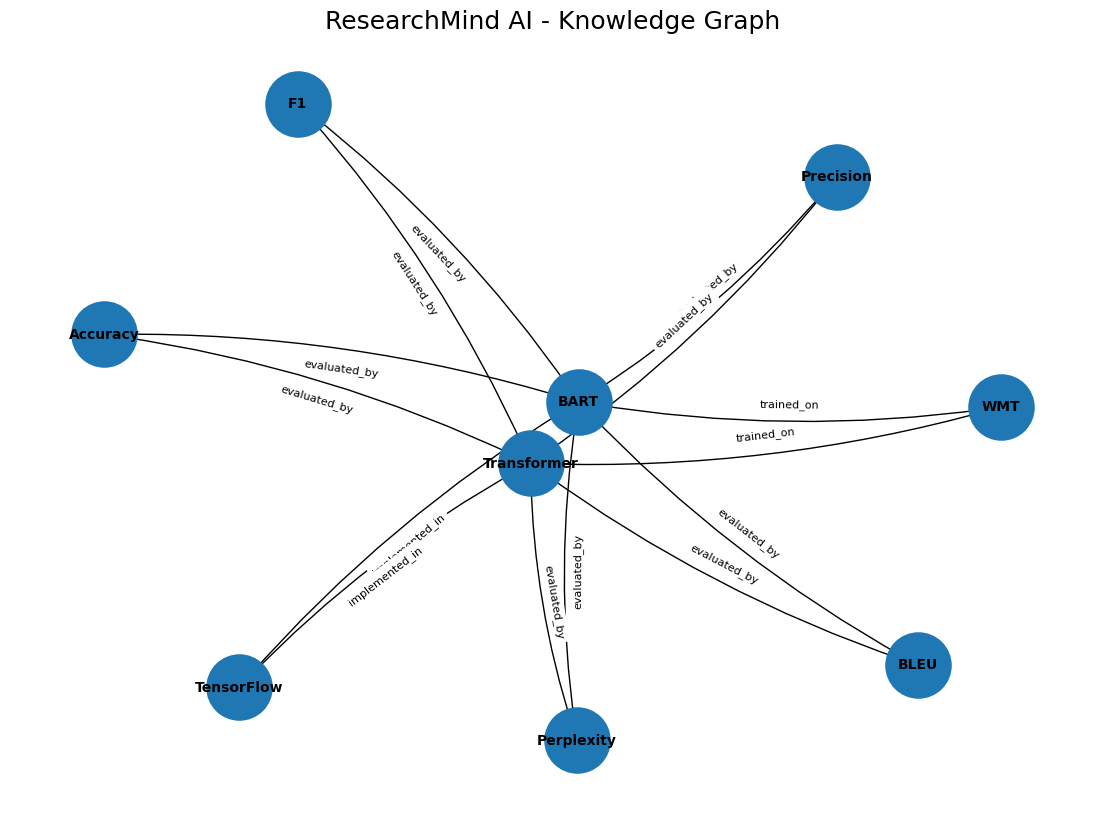

In [15]:
# ---------- 12. Knowledge Graph (Displayed in Colab) ----------

import networkx as nx
import matplotlib.pyplot as plt

# Build graph
models = entities.get("model", [])
datasets = entities.get("dataset", [])
frameworks = entities.get("framework", [])
metrics = entities.get("metric", [])

g = nx.MultiDiGraph()

for m in models:
    for d in datasets:
        g.add_edge(m, d, relation="trained_on")

    for f in frameworks:
        g.add_edge(m, f, relation="implemented_in")

    for me in metrics:
        g.add_edge(m, me, relation="evaluated_by")

print(f"\n=== Knowledge Graph ===")
print(f"Nodes : {g.number_of_nodes()}")
print(f"Edges : {g.number_of_edges()}")

# Plot
plt.figure(figsize=(14,10))

pos = nx.spring_layout(g, k=1.5, seed=42)

nx.draw_networkx_nodes(
    g,
    pos,
    node_size=2200
)

nx.draw_networkx_labels(
    g,
    pos,
    font_size=10,
    font_weight="bold"
)

nx.draw_networkx_edges(
    g,
    pos,
    arrows=True,
    arrowsize=18,
    connectionstyle="arc3,rad=0.08"
)

edge_labels = nx.get_edge_attributes(g, "relation")

nx.draw_networkx_edge_labels(
    g,
    pos,
    edge_labels=edge_labels,
    font_size=8
)

plt.title("ResearchMind AI - Knowledge Graph", fontsize=18)
plt.axis("off")
plt.show()

## Question Answering (Q&A) over Paper

In [16]:
def answer(question, context):
    prompt = f"Answer the question based on the context.\nContext: {context}\nQuestion: {question}\nAnswer:"
    return t5_generate(prompt, max_new_tokens=60)

QUESTIONS = [
    "What is the main model proposed?",
    "What dataset was used?",
    "What optimizer was used?",
    "What evaluation metric was used?",
]
print("\n=== Q&A over the paper ===")
for q in QUESTIONS:
    a = answer(q, text[:2500])
    print(f"Q: {q}\nA: {a}\n")



=== Q&A over the paper ===
Q: What is the main model proposed?
A: Transformer

Q: What dataset was used?
A: two machine translation tasks

Q: What optimizer was used?
A: Niki

Q: What evaluation metric was used?
A: Equal contribution. Listing order is random



## Find Similar Papers

In [17]:
from sentence_transformers import SentenceTransformer, util
import pandas as pd

print("\nLoading embedding model...")

embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

corpus = [
    {
        "Title": "Attention Is All You Need",
        "Domain": "Natural Language Processing",
        "Description": "Introduces the Transformer architecture."
    },
    {
        "Title": "YOLOv8",
        "Domain": "Computer Vision",
        "Description": "Real-time object detection on the COCO dataset."
    },
    {
        "Title": "BERT",
        "Domain": "Natural Language Processing",
        "Description": "Deep bidirectional Transformer pre-training."
    },
    {
        "Title": "Mamba",
        "Domain": "Sequence Modeling",
        "Description": "Linear-time State Space Model."
    },
    {
        "Title": "GPT-4 Technical Report",
        "Domain": "Large Language Models",
        "Description": "Large multimodal language model."
    },
]

query = final_summary[:500]

query_embedding = embedder.encode(
    query,
    convert_to_tensor=True,
    normalize_embeddings=True
)

paper_embeddings = embedder.encode(
    [p["Description"] for p in corpus],
    convert_to_tensor=True,
    normalize_embeddings=True
)

scores = util.cos_sim(query_embedding, paper_embeddings)[0]

results = []

for idx in scores.argsort(descending=True):

    results.append({
        "Paper": corpus[int(idx)]["Title"],
        "Domain": corpus[int(idx)]["Domain"],
        "Similarity Score": round(float(scores[idx]), 3)
    })

df = pd.DataFrame(results)

print("\n========== Similar Papers ==========\n")

display(df)


Loading embedding model...

========== Similar Papers ==========



,Paper,Domain,Similarity Score
0,BERT,Natural Language Processing,0.475
1,GPT-4 Technical Report,Large Language Models,0.418
2,Attention Is All You Need,Natural Language Processing,0.316
3,YOLOv8,Computer Vision,0.267
4,Mamba,Sequence Modeling,0.232
